# Etapa 6 - Índice operacional de vulnerabilidad

Ejecutar en orden desde el repositorio o notebooks/. Dependencias: pandas, numpy, openpyxl, matplotlib e IPython. Genera una copia analítica con cuatro columnas nuevas, el informe y cuatro figuras. La definición es la autorizada por el equipo: no es clínica, oficial ni diagnóstica. No sobrescribe fuentes ni entregables anteriores.

In [1]:
from pathlib import Path
from itertools import product
import hashlib, re, platform
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
root=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"data/processed/dataset_salud_publica_limpio.xlsx").exists())
source=root/"data/processed/dataset_salud_publica_limpio.xlsx"
protected=[source,root/"dataset_salud_publica_2500.xlsx"]+[p for folder in ["reports","notebooks"] for p in (root/folder).glob("0[12345]*") if p.is_file()]+[p for sub in ["eda","relaciones"] for p in (root/"outputs/figuras"/sub).glob("*.png")]
hashes={p:hashlib.sha256(p.read_bytes()).hexdigest() for p in protected}
previous={p.name:p.read_text(encoding="utf-8") for p in (root/"reports").glob("0[12345]*.md")}
df=pd.read_excel(source,sheet_name="Salud Publica",engine="openpyxl")
snapshot=df.copy(deep=True)
assert df.shape==(2500,10)
assert df.Condicion_Salud.notna().all() and df.Acceso_Medicacion.notna().all()
assert set(df.Condicion_Salud)<= {"Saludable","Aguda","Crónica"}
assert set(df.Acceso_Medicacion)<= {"Sí","No"}
assert df.Tiempo_Espera_min.quantile(.75)==99
# Función limitada estructuralmente a las tres variables autorizadas.
def dimensions(condition,medication,wait):
    d=pd.DataFrame(index=condition.index)
    d["Dim_Necesidad"]=condition.eq("Crónica").astype("Int64").mask(condition.isna())
    d["Dim_Medicacion"]=medication.eq("No").astype("Int64").mask(medication.isna())
    d["Dim_Espera"]=wait.ge(99).astype("Int64").mask(wait.isna())
    d["Score_Vulnerabilidad"]=d.sum(axis=1,min_count=3).astype("Int64")
    return d
derived=dimensions(df.Condicion_Salud,df.Acceso_Medicacion,df.Tiempo_Espera_min)
analysis=pd.concat([df.copy(deep=True),derived],axis=1)
dimcols=["Dim_Necesidad","Dim_Medicacion","Dim_Espera"]
score="Score_Vulnerabilidad"
evaluated=analysis.loc[analysis[score].notna()].copy()
n=len(evaluated)
missing=int(analysis[score].isna().sum())
out=root/"outputs/figuras/vulnerabilidad"
out.mkdir(parents=True,exist_ok=True)
plt.rcParams.update({"font.family":"DejaVu Sans","font.size":12,"axes.titlesize":15,"axes.spines.top":False,"axes.spines.right":False,"savefig.dpi":180})
parts,figures=[],[]
def emit(s):
    parts.append(s)
    display(Markdown(s))
def table(headers,rows,numeric=()):
    rows=[[f"{v:.2f}" if isinstance(v,(float,np.floating)) else str(v) for v in r] for r in rows]
    widths=[max(3,len(h),*(len(r[j]) for r in rows)) for j,h in enumerate(headers)]
    lines=["| "+" | ".join(h.ljust(widths[j]) for j,h in enumerate(headers))+" |","| "+" | ".join("-"*(w-1)+":" if j in numeric else "-"*w for j,w in enumerate(widths))+" |"]
    lines+=["| "+" | ".join(v.rjust(widths[j]) if j in numeric else v.ljust(widths[j]) for j,v in enumerate(r))+" |" for r in rows]
    return "\n".join(lines)
def save(fig,ax,name,why):
    assert ax.has_data()
    fig.tight_layout()
    p=out/name
    fig.savefig(p,bbox_inches="tight",facecolor="white")
    plt.close(fig)
    assert plt.imread(p).std()>.01
    figures.append(p)
    emit(f"**Visualización:** {why}\n\n![{name}](../outputs/figuras/vulnerabilidad/{name})")
    display(Image(filename=str(p)))
def stacked(pc,labels,title,xlabel,name,why,legend):
    fig,ax=plt.subplots(figsize=(11,6))
    colors=["#D7E3E8","#8FBCCB","#397A95","#283E62"] if len(pc.columns)==4 else ["#B66E50","#D7A27D","#DCDACB","#8FBCCB","#397A95"]
    bottom=np.zeros(len(pc))
    for j,c in enumerate(pc.columns):
        values=pc[c].to_numpy(dtype=float)
        ax.bar(range(len(pc)),values,bottom=bottom,label=f"{legend} {c}",color=colors[j],width=.66)
        for i,v in enumerate(values):
            if v>=2.5:
                ax.text(i,bottom[i]+v/2,f"{v:.1f}%",ha="center",va="center",fontsize=10,color="white" if j>=len(colors)-2 else "#26394A")
        bottom+=values
    assert np.allclose(bottom,100)
    ax.set(xticks=range(len(pc)),xticklabels=labels,title=title,xlabel=xlabel,ylabel="Porcentaje dentro del grupo evaluable (%)",ylim=(0,100))
    ax.legend(loc="upper center",bbox_to_anchor=(.5,-.18),ncol=len(pc.columns),frameon=False)
    save(fig,ax,name,why)
emit("# Etapa 6 - Índice operacional de vulnerabilidad\n\n## 1. Objetivo\n\n"
     "Construir y describir el **Índice operacional de vulnerabilidad en el acceso y la atención**, definido por el equipo para estudiar la acumulación de dimensiones observables en el dataset ficticio. "
     "El dataset no contiene una variable original de vulnerabilidad. Este índice no es una verdad clínica, diagnóstico ni definición oficial, y no debe generalizarse a población real. "
     "Un registro con score X presenta X dimensiones según esta definición operacional; no se etiqueta al paciente como vulnerable.\n\n"
     "Se leyeron los cinco informes anteriores. Esta etapa es descriptiva: no se agregan pruebas estadísticas, modelos, dashboard ni recomendaciones. "
     "Los porcentajes se calculan con casos evaluables en las variables requeridas; pueden sumar 99.99% o 100.01% por redondeo.")
emit("## 2. Definición operacional\n\n"+table(["Dimensión","1 punto","0 puntos","Si falta información"],[
    ["Dim_Necesidad","Condicion_Salud = Crónica","Otra condición","NA"],
    ["Dim_Medicacion","Acceso_Medicacion = No","Acceso_Medicacion = Sí","NA"],
    ["Dim_Espera","Tiempo_Espera_min ≥ 99","Tiempo_Espera_min < 99","NA"]])+
    "\n\nScore_Vulnerabilidad es la suma de las tres dimensiones **solo cuando todas son observables**, con valores 0, 1, 2, 3 o NA. "
    "Cada dimensión pesa un punto. El umbral se fija en 99 minutos por decisión del equipo, correspondiente al Q3 del EDA; no se recalcula por región o cobertura. "
    "Se incluye el valor exacto 99. Cobertura, región y satisfacción no participan en la fórmula. "
    "No se crean categorías bajo/medio/alto ni una clasificación binaria.")


# Etapa 6 - Índice operacional de vulnerabilidad

## 1. Objetivo

Construir y describir el **Índice operacional de vulnerabilidad en el acceso y la atención**, definido por el equipo para estudiar la acumulación de dimensiones observables en el dataset ficticio. El dataset no contiene una variable original de vulnerabilidad. Este índice no es una verdad clínica, diagnóstico ni definición oficial, y no debe generalizarse a población real. Un registro con score X presenta X dimensiones según esta definición operacional; no se etiqueta al paciente como vulnerable.

Se leyeron los cinco informes anteriores. Esta etapa es descriptiva: no se agregan pruebas estadísticas, modelos, dashboard ni recomendaciones. Los porcentajes se calculan con casos evaluables en las variables requeridas; pueden sumar 99.99% o 100.01% por redondeo.

## 2. Definición operacional

| Dimensión      | 1 punto                   | 0 puntos               | Si falta información |
| -------------- | ------------------------- | ---------------------- | -------------------- |
| Dim_Necesidad  | Condicion_Salud = Crónica | Otra condición         | NA                   |
| Dim_Medicacion | Acceso_Medicacion = No    | Acceso_Medicacion = Sí | NA                   |
| Dim_Espera     | Tiempo_Espera_min ≥ 99    | Tiempo_Espera_min < 99 | NA                   |

Score_Vulnerabilidad es la suma de las tres dimensiones **solo cuando todas son observables**, con valores 0, 1, 2, 3 o NA. Cada dimensión pesa un punto. El umbral se fija en 99 minutos por decisión del equipo, correspondiente al Q3 del EDA; no se recalcula por región o cobertura. Se incluye el valor exacto 99. Cobertura, región y satisfacción no participan en la fórmula. No se crean categorías bajo/medio/alto ni una clasificación binaria.

## 3. Manejo de datos faltantes

| Estado              | N    | Porcentaje sobre 2500 |
| ------------------- | ---: | --------------------: |
| Score calculable    | 2426 |                 97.04 |
| Score no calculable |   74 |                  2.96 |

Los 74 NA de espera se conservan como NA en Dim_Espera y Score_Vulnerabilidad. Dim_Necesidad y Dim_Medicacion tienen 2500 valores observables, y Dim_Espera tiene 2426. Un score NA no equivale a cero dimensiones. La suma exige tres componentes presentes (min_count=3); no se imputa. Los 72 NA de satisfacción no impiden calcular el score si las tres dimensiones están presentes; sí se excluyen al describir satisfacción. No se eliminan filas de la copia analítica.

## 4. Distribución del score

Pregunta: ¿cuántas dimensiones operacionales se acumulan en los registros evaluables? N efectivo=2426; NA del score=74.

| Score | Frecuencia | Porcentaje evaluable |
| ----: | ---------: | -------------------: |
|     0 |        904 |                37.26 |
|     1 |        937 |                38.62 |
|     2 |        471 |                19.41 |
|     3 |        114 |                 4.70 |

**Visualización:** Barras ordenadas 0–3 comparan la frecuencia de cada cantidad de dimensiones; los NA quedan fuera del denominador y se informan aparte.

![score_vulnerabilidad_distribucion.png](../outputs/figuras/vulnerabilidad/score_vulnerabilidad_distribucion.png)

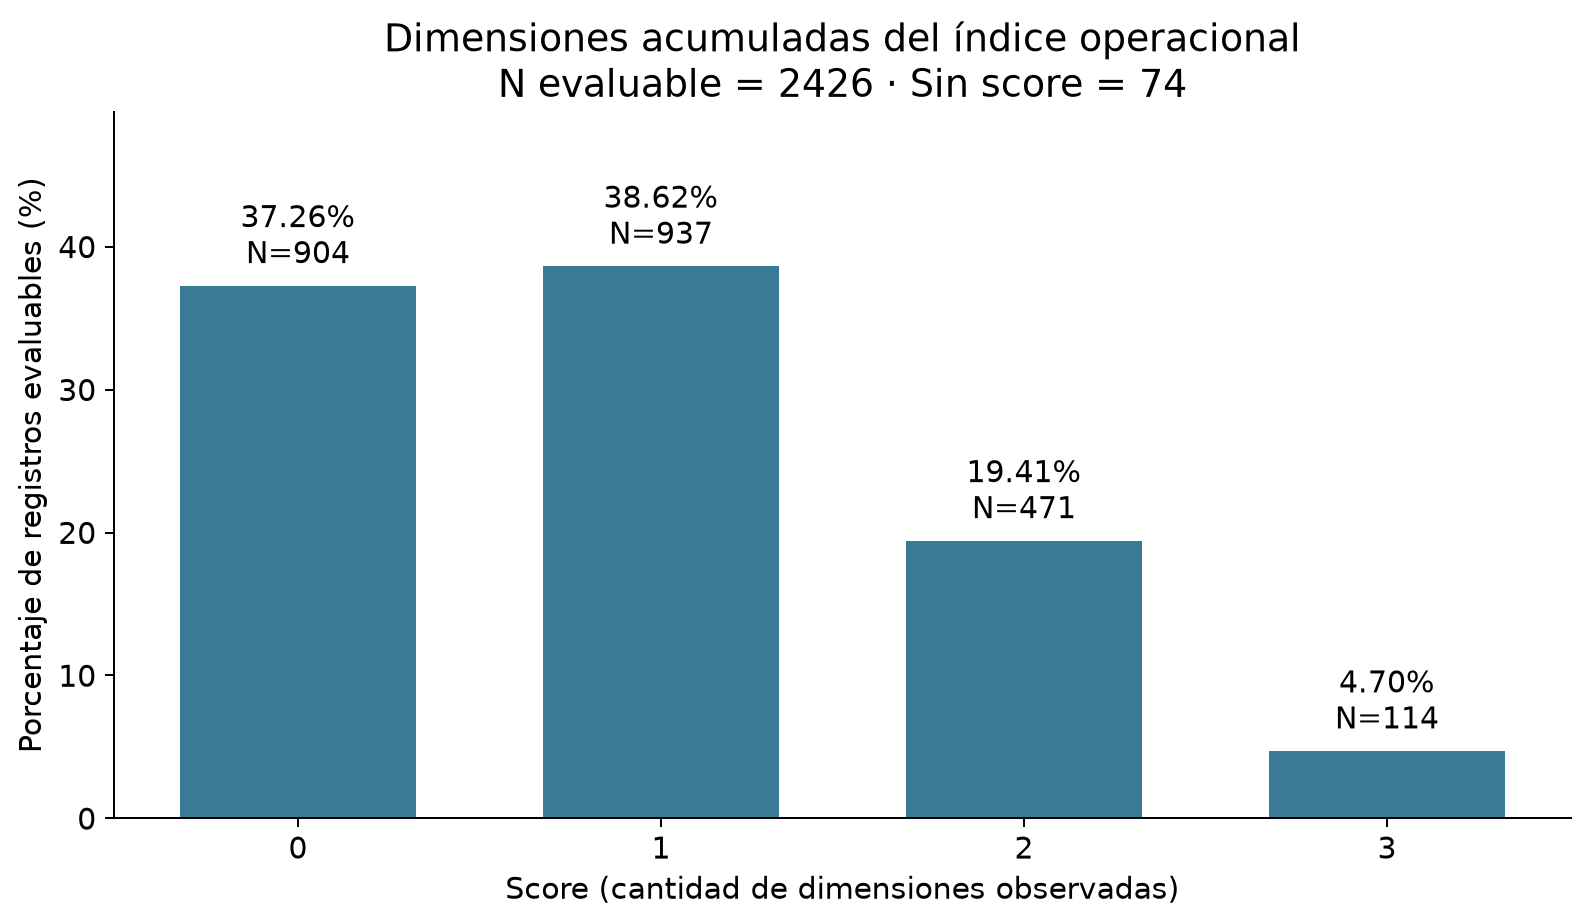

## 5. Composición del score

| Dim_Necesidad | Dim_Medicacion | Dim_Espera | Score | N   | Porcentaje de evaluables |
| ------------: | -------------: | ---------: | ----: | --: | -----------------------: |
|             0 |              0 |          0 |     0 | 904 |                    37.26 |
|             0 |              0 |          1 |     1 | 237 |                     9.77 |
|             0 |              1 |          0 |     1 | 285 |                    11.75 |
|             1 |              0 |          0 |     1 | 415 |                    17.11 |
|             0 |              1 |          1 |     2 | 176 |                     7.25 |
|             1 |              0 |          1 |     2 |  87 |                     3.59 |
|             1 |              1 |          0 |     2 | 208 |                     8.57 |
|             1 |              1 |          1 |     3 | 114 |                     4.70 |

Orden de componentes: necesidad, medicación, espera. Combinaciones más frecuentes: (0,0,0): 904 (37.26%); (1,0,0): 415 (17.11%); (0,1,0): 285 (11.75%). La combinación (0,0,0) no activa ninguna de las tres dimensiones. Los scores 1 y 2 reúnen tres perfiles diferentes cada uno; no describen un mismo problema ni una gravedad clínica homogénea.

In [2]:
emit("## 3. Manejo de datos faltantes\n\n"+table(["Estado","N","Porcentaje sobre 2500"],[
    ["Score calculable",n,n/len(df)*100],["Score no calculable",missing,missing/len(df)*100]],numeric=(1,2))+
    "\n\nLos 74 NA de espera se conservan como NA en Dim_Espera y Score_Vulnerabilidad. "
    "Dim_Necesidad y Dim_Medicacion tienen 2500 valores observables, y Dim_Espera tiene 2426. "
    "Un score NA no equivale a cero dimensiones. La suma exige tres componentes presentes (min_count=3); no se imputa. "
    "Los 72 NA de satisfacción no impiden calcular el score si las tres dimensiones están presentes; sí se excluyen al describir satisfacción. "
    "No se eliminan filas de la copia analítica.")
freq=evaluated[score].value_counts().reindex([0,1,2,3],fill_value=0)
pct=freq/n*100
assert freq.sum()==n and np.isclose(pct.sum(),100)
emit("## 4. Distribución del score\n\n"
     f"Pregunta: ¿cuántas dimensiones operacionales se acumulan en los registros evaluables? N efectivo={n}; NA del score={missing}.\n\n"+
     table(["Score","Frecuencia","Porcentaje evaluable"],[[s,int(freq[s]),pct[s]] for s in range(4)],numeric=(0,1,2)))
fig,ax=plt.subplots(figsize=(9,5.3))
bars=ax.bar(["0","1","2","3"],pct.to_numpy(dtype=float),color="#397A95",width=.65)
ax.bar_label(bars,labels=[f"{pct[s]:.2f}%\nN={freq[s]}" for s in range(4)],padding=5)
ax.set(title=f"Dimensiones acumuladas del índice operacional\nN evaluable = {n} · Sin score = {missing}",xlabel="Score (cantidad de dimensiones observadas)",ylabel="Porcentaje de registros evaluables (%)",ylim=(0,float(pct.max())*1.28))
save(fig,ax,"score_vulnerabilidad_distribucion.png","Barras ordenadas 0–3 comparan la frecuencia de cada cantidad de dimensiones; los NA quedan fuera del denominador y se informan aparte.")
emit("## 5. Composición del score")
combination_rows=[]
for dims in product([0,1],repeat=3):
    count=int((evaluated[dimcols].eq(dims).all(axis=1)).sum())
    combination_rows.append([*dims,sum(dims),count,count/n*100])
combination_rows.sort(key=lambda r:(r[3],r[0],r[1],r[2]))
assert sum(r[4] for r in combination_rows)==n
for s in range(4):
    assert sum(r[4] for r in combination_rows if r[3]==s)==freq[s]
emit(table(["Dim_Necesidad","Dim_Medicacion","Dim_Espera","Score","N","Porcentaje de evaluables"],combination_rows,numeric=(0,1,2,3,4,5)))
top=sorted(combination_rows,key=lambda r:r[4],reverse=True)[:3]
top_text="; ".join(f"({r[0]},{r[1]},{r[2]}): {r[4]} ({r[5]:.2f}%)" for r in top)
emit("Orden de componentes: necesidad, medicación, espera. Combinaciones más frecuentes: "+top_text+
     ". La combinación (0,0,0) no activa ninguna de las tres dimensiones. "
     "Los scores 1 y 2 reúnen tres perfiles diferentes cada uno; no describen un mismo problema ni una gravedad clínica homogénea.")


## 6. Score según cobertura

Cobertura se utiliza únicamente para segmentar. Los porcentajes se calculan dentro de cada cobertura con score observable.

| Cobertura_Salud | N evaluable | Sin score | Score 0 % | Score 1 % | Score 2 % | Score 3 % |
| --------------- | ----------: | --------: | --------: | --------: | --------: | --------: |
| Privada         |         823 |        20 |     56.99 |     35.12 |      7.90 |      0.00 |
| Pública         |         777 |        29 |     39.12 |     39.51 |     18.28 |      3.09 |
| Sin cobertura   |         826 |        25 |     15.86 |     41.28 |     31.96 |     10.90 |

**Visualización:** Barras apiladas al 100% comparan el reparto de scores 0–3 dentro de cada cobertura, conservando orden, colores y denominadores.

![score_por_cobertura.png](../outputs/figuras/vulnerabilidad/score_por_cobertura.png)

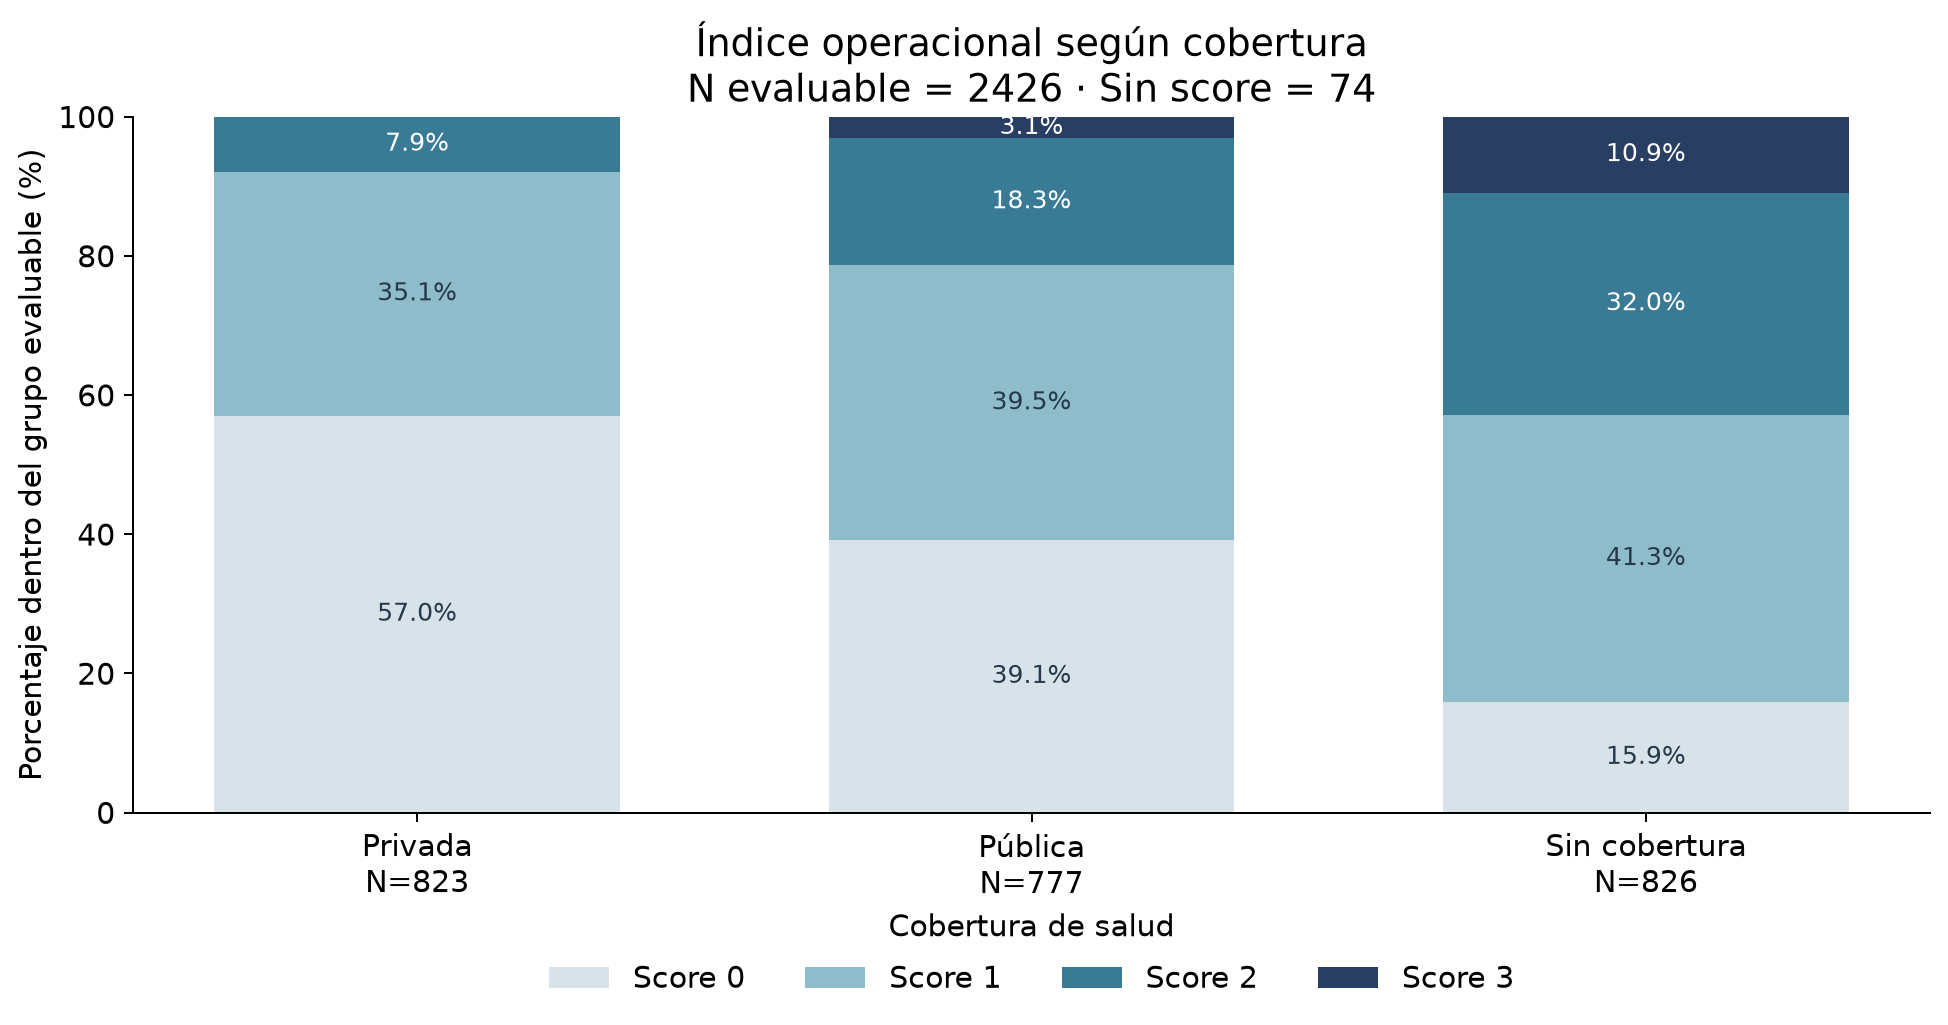

Privada: score 0=56.99%, score 3=0.00% (N=823); Pública: score 0=39.12%, score 3=3.09% (N=777); Sin cobertura: score 0=15.86%, score 3=10.90% (N=826). Son diferencias descriptivas. La ausencia de score 3 en Privada es coherente con que sus esperas observadas no alcanzan 99 minutos; no implica ausencia de toda dificultad.

## 7. Score según región

Porcentajes dentro de cada región evaluable; región no forma parte de la definición.

| Region       | N evaluable | Sin score | Score 0 % | Score 1 % | Score 2 % | Score 3 % |
| ------------ | ----------: | --------: | --------: | --------: | --------: | --------: |
| Norte        |         466 |        18 |     34.33 |     39.48 |     22.32 |      3.86 |
| Centro       |         484 |        11 |     38.64 |     34.50 |     21.69 |      5.17 |
| Sur          |         492 |        13 |     37.20 |     40.24 |     18.50 |      4.07 |
| CABA         |         479 |        19 |     38.00 |     42.80 |     13.78 |      5.43 |
| Buenos Aires |         505 |        13 |     38.02 |     36.24 |     20.79 |      4.95 |

| Score | Mínimo regional % | Máximo regional % | Amplitud (puntos porcentuales) |
| ----: | ----------------: | ----------------: | -----------------------------: |
|     0 |             34.33 |             38.64 |                           4.30 |
|     1 |             34.50 |             42.80 |                           8.29 |
|     2 |             13.78 |             22.32 |                           8.54 |
|     3 |              3.86 |              5.43 |                           1.57 |

Score 2: CABA=13.78% frente a Norte=22.32% (amplitud 8.54 puntos porcentuales). Se incluye una figura porque esta diferencia y la variación del score 1 aportan contraste descriptivo; la decisión es editorial, no un umbral de significación o relevancia clínica. No se afirma una desigualdad territorial demostrada.

**Visualización:** Barras apiladas al 100% permiten comparar las cuatro proporciones regionales con la misma escala; las diferencias se cuantifican en la tabla.

![score_por_region.png](../outputs/figuras/vulnerabilidad/score_por_region.png)

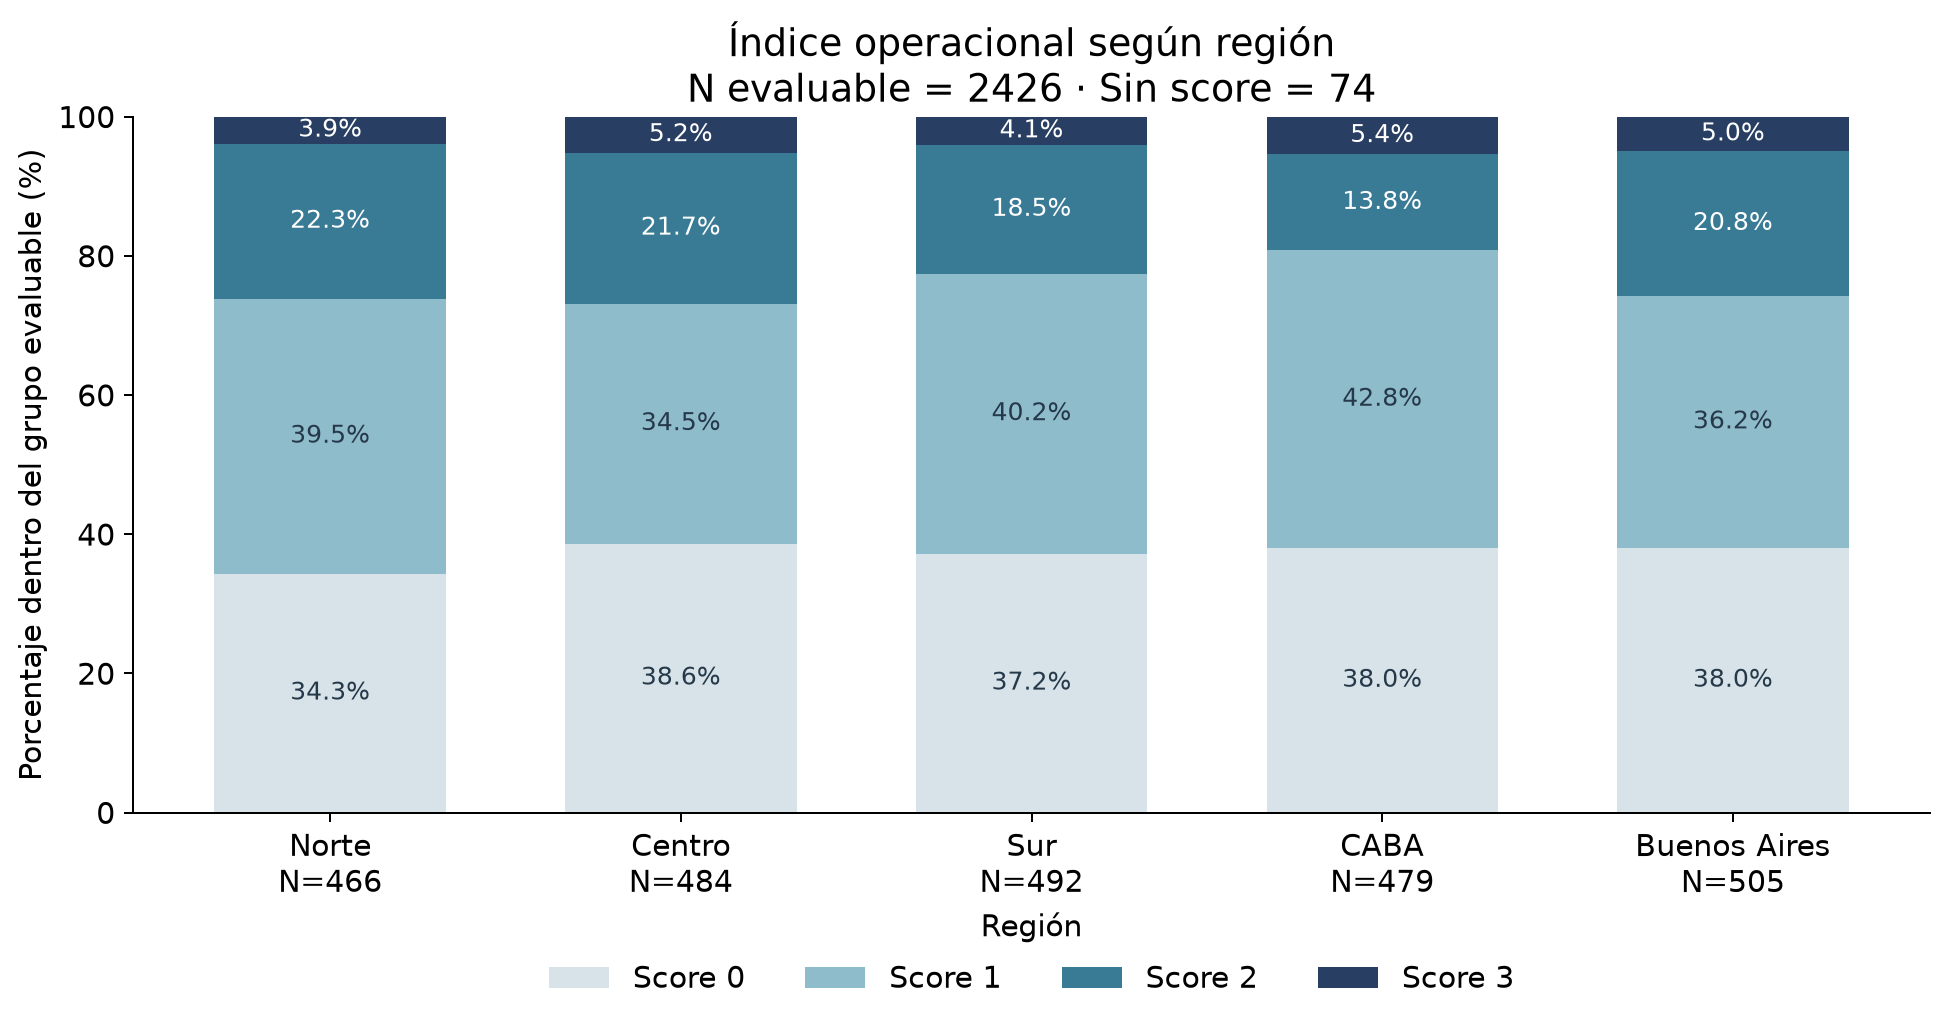

In [3]:
def segment(group,order):
    ct=pd.crosstab(evaluated[group],evaluated[score]).reindex(index=order,columns=[0,1,2,3],fill_value=0)
    ns=ct.sum(axis=1)
    pc=ct.div(ns,axis=0)*100
    assert ns.sum()==n and np.allclose(pc.sum(axis=1),100)
    rows=[]
    for k in order:
        total=int(analysis[group].eq(k).sum())
        rows.append([k,int(ns[k]),total-int(ns[k]),*pc.loc[k].tolist()])
    emit(table([group,"N evaluable","Sin score","Score 0 %","Score 1 %","Score 2 %","Score 3 %"],rows,numeric=(1,2,3,4,5,6)))
    return ct,ns,pc
emit("## 6. Score según cobertura\n\nCobertura se utiliza únicamente para segmentar. Los porcentajes se calculan dentro de cada cobertura con score observable.")
covct,covn,covpct=segment("Cobertura_Salud",["Privada","Pública","Sin cobertura"])
stacked(covpct,[f"{k}\nN={covn[k]}" for k in covpct.index],f"Índice operacional según cobertura\nN evaluable = {n} · Sin score = {missing}","Cobertura de salud",
        "score_por_cobertura.png","Barras apiladas al 100% comparan el reparto de scores 0–3 dentro de cada cobertura, conservando orden, colores y denominadores.","Score")
cov_observation="; ".join(f"{k}: score 0={covpct.loc[k,0]:.2f}%, score 3={covpct.loc[k,3]:.2f}% (N={covn[k]})" for k in covpct.index)
emit(cov_observation+". Son diferencias descriptivas. "
     "La ausencia de score 3 en Privada es coherente con que sus esperas observadas no alcanzan 99 minutos; no implica ausencia de toda dificultad.")
emit("## 7. Score según región\n\nPorcentajes dentro de cada región evaluable; región no forma parte de la definición.")
regct,regn,regpct=segment("Region",["Norte","Centro","Sur","CABA","Buenos Aires"])
regional_ranges=regpct.max()-regpct.min()
emit(table(["Score","Mínimo regional %","Máximo regional %","Amplitud (puntos porcentuales)"],
           [[s,regpct[s].min(),regpct[s].max(),regional_ranges[s]] for s in range(4)],numeric=(0,1,2,3)))
regional_observation=f"Score 2: {regpct[2].idxmin()}={regpct[2].min():.2f}% frente a {regpct[2].idxmax()}={regpct[2].max():.2f}% (amplitud {regional_ranges[2]:.2f} puntos porcentuales)."
emit(regional_observation+" Se incluye una figura porque esta diferencia y la variación del score 1 aportan contraste descriptivo; "
     "la decisión es editorial, no un umbral de significación o relevancia clínica. No se afirma una desigualdad territorial demostrada.")
stacked(regpct,[f"{k}\nN={regn[k]}" for k in regpct.index],f"Índice operacional según región\nN evaluable = {n} · Sin score = {missing}","Región",
        "score_por_region.png","Barras apiladas al 100% permiten comparar las cuatro proporciones regionales con la misma escala; las diferencias se cuantifican en la tabla.","Score")


## 8. Score y satisfacción

Pregunta: ¿cómo cambia la distribución de satisfacción al acumular dimensiones? **N efectivo=2357**; excluidos por ausencia de score o satisfacción=143. Entre los 2426 registros evaluables del índice, 69 carecen de satisfacción. Son 74 sin score más 72 sin satisfacción, con 3 coincidentes: 143 exclusiones únicas.

| Score | N con satisfacción | NA satisfacción entre evaluables | Mediana | Moda | Nivel 1 % | Nivel 2 % | Nivel 3 % | Nivel 4 % | Nivel 5 % |
| ----: | -----------------: | -------------------------------: | ------: | ---- | --------: | --------: | --------: | --------: | --------: |
|     0 |                874 |                               30 |    4.00 | 5    |      0.00 |      0.00 |     12.24 |     43.48 |     44.28 |
|     1 |                912 |                               25 |    4.00 | 4    |      1.43 |     14.36 |     30.48 |     33.88 |     19.85 |
|     2 |                457 |                               14 |    3.00 | 3    |     15.97 |     31.95 |     33.70 |     16.63 |      1.75 |
|     3 |                114 |                                0 |    2.00 | 1    |     42.11 |     38.60 |     19.30 |      0.00 |      0.00 |

**Visualización:** Barras apiladas al 100% por score conservan el orden de satisfacción 1–5. Cada barra usa su N con ambas variables disponibles; no se calcula media de satisfacción.

![satisfaccion_por_score.png](../outputs/figuras/vulnerabilidad/satisfaccion_por_score.png)

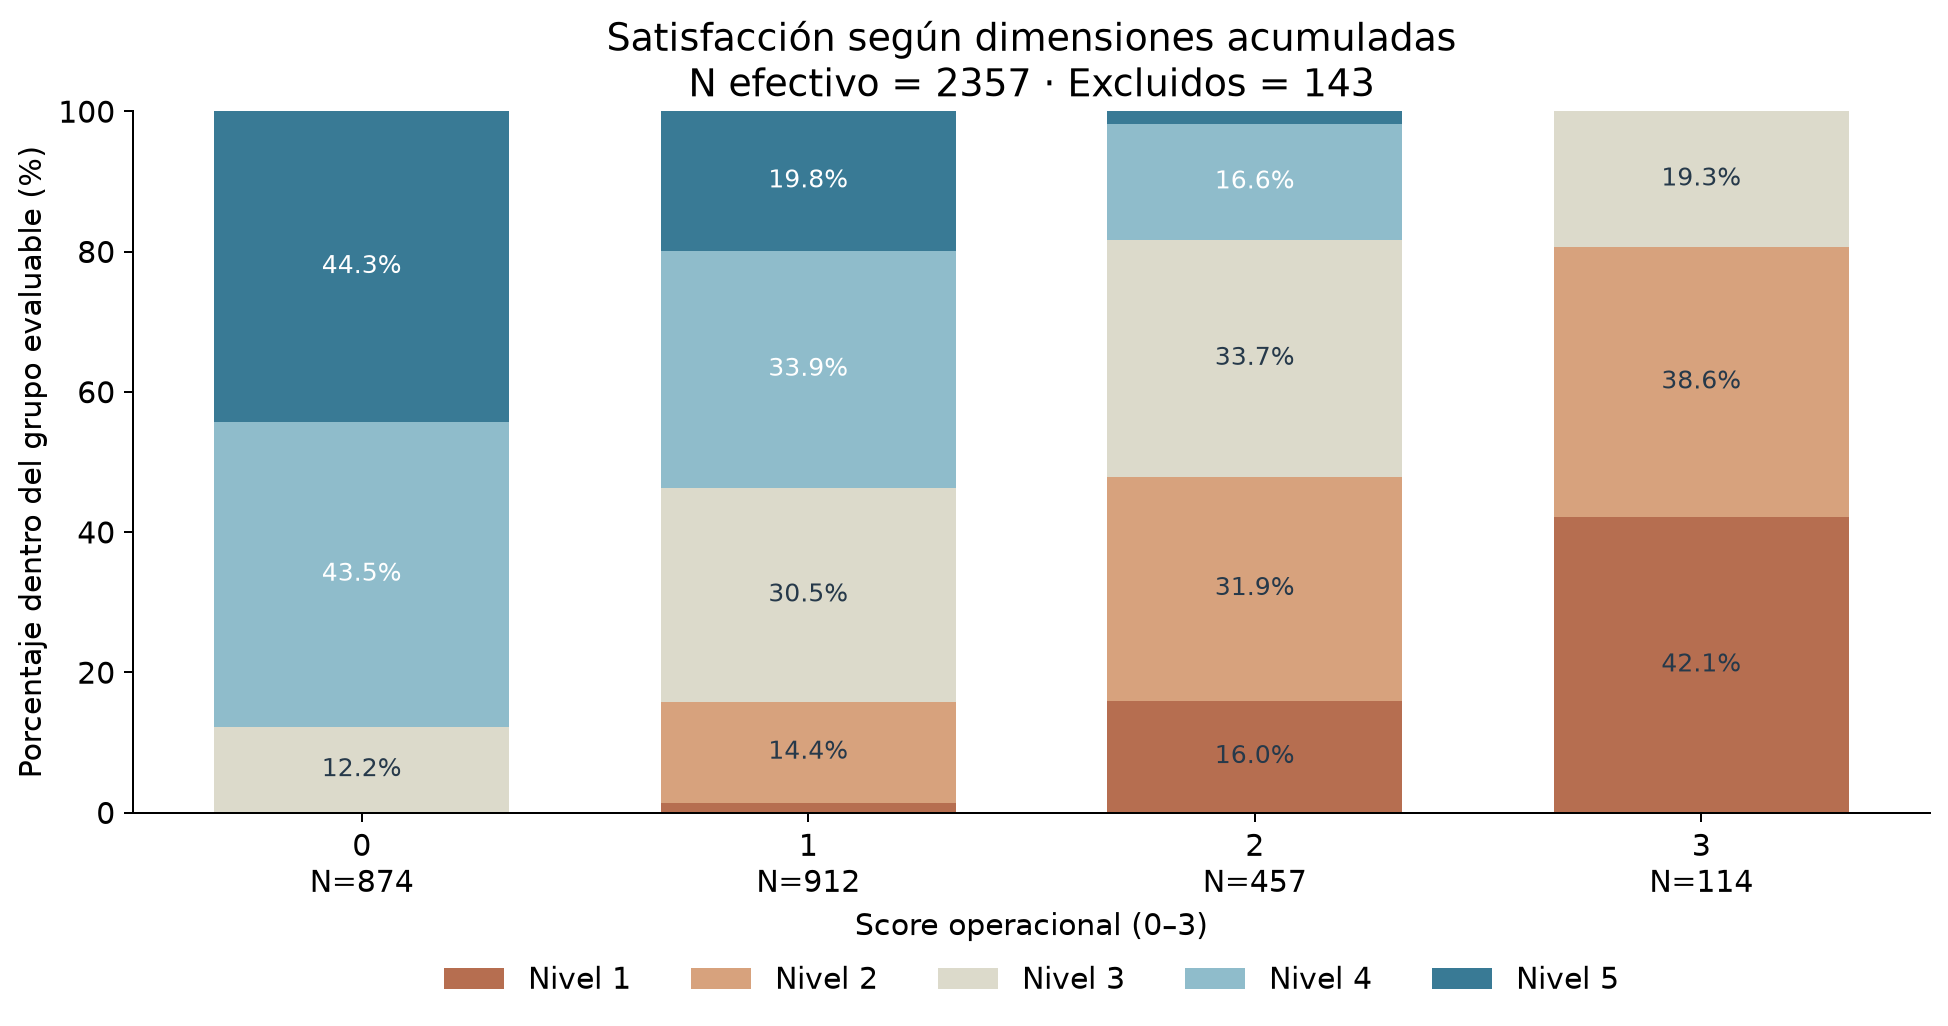

score 0: mediana 4, moda 5 (N=874); score 1: mediana 4, moda 4 (N=912); score 2: mediana 3, moda 3 (N=457); score 3: mediana 2, moda 1 (N=114). Se observa desplazamiento descriptivo hacia niveles inferiores, aunque la mediana es igual para scores 0 y 1. Satisfacción no interviene en la fórmula: es un resultado externo al cálculo, pero no es evidencia externa independiente, pues procede del mismo dataset sintético y ya se relacionaba con espera y acceso en el caso. No constituye validación clínica ni causal.

In [4]:
emit("## 8. Score y satisfacción")
paired=analysis.loc[analysis[[score,"Satisfaccion"]].notna().all(axis=1)].copy()
satct=pd.crosstab(paired[score],paired.Satisfaccion).reindex(index=[0,1,2,3],columns=[1,2,3,4,5],fill_value=0)
satn=satct.sum(axis=1)
satpct=satct.div(satn,axis=0)*100
assert satn.sum()==len(paired)==2357 and np.allclose(satpct.sum(axis=1),100)
satrows=[]
for s in range(4):
    values=paired.loc[paired[score].eq(s),"Satisfaccion"]
    satrows.append([s,len(values),int(freq[s]-len(values)),values.median(),", ".join(str(int(v)) for v in values.mode()),*satpct.loc[s].tolist()])
emit(f"Pregunta: ¿cómo cambia la distribución de satisfacción al acumular dimensiones? **N efectivo={len(paired)}**; "
     f"excluidos por ausencia de score o satisfacción={len(df)-len(paired)}. Entre los {n} registros evaluables del índice, "
     f"{n-len(paired)} carecen de satisfacción. Son 74 sin score más 72 sin satisfacción, con 3 coincidentes: 143 exclusiones únicas.\n\n"+
     table(["Score","N con satisfacción","NA satisfacción entre evaluables","Mediana","Moda","Nivel 1 %","Nivel 2 %","Nivel 3 %","Nivel 4 %","Nivel 5 %"],satrows,numeric=(0,1,2,3,5,6,7,8,9)))
stacked(satpct,[f"{s}\nN={satn[s]}" for s in range(4)],f"Satisfacción según dimensiones acumuladas\nN efectivo = {len(paired)} · Excluidos = {len(df)-len(paired)}","Score operacional (0–3)",
        "satisfaccion_por_score.png","Barras apiladas al 100% por score conservan el orden de satisfacción 1–5. Cada barra usa su N con ambas variables disponibles; no se calcula media de satisfacción.","Nivel")
sat_observation="; ".join(f"score {r[0]}: mediana {r[3]:.0f}, moda {r[4]} (N={r[1]})" for r in satrows)
emit(sat_observation+". Se observa desplazamiento descriptivo hacia niveles inferiores, aunque la mediana es igual para scores 0 y 1. "
     "Satisfacción no interviene en la fórmula: es un resultado externo al cálculo, pero no es evidencia externa independiente, "
     "pues procede del mismo dataset sintético y ya se relacionaba con espera y acceso en el caso. No constituye validación clínica ni causal.")


In [5]:
emit("## 9. Evaluación crítica del índice\n\n"+
     table(["Aspecto","Evaluación"],[
     ["Distribución",f"Score 0: {freq[0]}; 1: {freq[1]}; 2: {freq[2]}; 3: {freq[3]} (N={n})."],
     ["Categorías pequeñas",f"Score 3 es el menor: {freq[3]} ({pct[3]:.2f}%). Permite descripción agregada, no garantiza precisión ni representatividad."],
     ["N del score 3",f"N={freq[3]}, también {satn[3]} con satisfacción. Una observación equivale a {100/freq[3]:.2f} puntos porcentuales; subdividirlo reduce estabilidad."],
     ["Perfiles", "Distingue cantidad de dimensiones, pero combina perfiles diferentes dentro de scores 1 y 2. No está validado como escala de gravedad."],
     ["Cobertura",cov_observation+"; no implica causalidad."],
     ["Satisfacción",sat_observation+"; patrón descriptivo, sin prueba ni media."],
     ["Umbral 99","Q3 es relativo a esta muestra, no un estándar de oportunidad. La dicotomía separa valores cercanos como 98 y 99 y equipara todas las esperas ≥99."],
     ["Pesos iguales","Supone intercambiabilidad de las dimensiones y pierde identidad, intensidad y secuencia; un punto no tiene significado clínico calibrado."]])+
     "\n\nLos subgrupos score 3 por cobertura tienen N=0 en Privada, N=24 en Pública y N=90 en Sin cobertura; no se debe trasladar automáticamente la estabilidad del total a cada segmento. "
     "Score 0 significa ausencia de estas tres condiciones operacionales, no ausencia de dificultades en general. "
     "La condición crónica representa aquí necesidad por decisión del equipo, no una barrera por sí misma; las condiciones agudas también pueden requerir atención, aspecto no recogido por ese componente. "
     "La definición no se modifica.")
wait_on=int(derived.Dim_Espera.eq(1).sum())
eq99=int(df.Tiempo_Espera_min.eq(99).sum())
emit(f"El umbral incluye {wait_on} de {n} esperas disponibles ({wait_on/n*100:.2f}%). Hay {eq99} valores exactamente iguales a 99; "
     "el uso de ≥ y los empates implican que no tiene por qué activarse exactamente en el 25% de los casos.")
emit("## 10. Hallazgos")
findings=[
(f"Score calculable en {n}/2500 ({n/2500*100:.2f}%); 74 sin score.",
 "Se puede describir la acumulación en los casos con las tres dimensiones observables.","No se considera score 0 a los registros sin información ni se caracteriza su acumulación completa."),
(f"Scores 0/1/2/3: {freq[0]}/{freq[1]}/{freq[2]}/{freq[3]} (N={n}); score 3={pct[3]:.2f}%.",
 "Los cuatro valores tienen representación; predomina score 1.","Frecuencia no equivale a gravedad clínica y el grupo 3 pierde precisión al subdividirse."),
(top_text+f"; N={n}.","La suma reúne perfiles distintos; interpretar sus componentes evita tratarlos como problemas idénticos.","Los pesos iguales no cuantifican severidad ni establecen equivalencia clínica."),
(cov_observation+".","La composición del índice cambia descriptivamente entre coberturas.","La cobertura no participa en la fórmula y estas diferencias no prueban causalidad ni efectos independientes."),
(regional_observation+f"; N regional: "+", ".join(f"{k}={regn[k]}" for k in regn.index)+".",
 "La figura regional aporta una comparación descriptiva adicional.","No se evaluó significación, incertidumbre ni relevancia territorial externa."),
(sat_observation+".","Hay un patrón descriptivo de satisfacción distinto a medida que se acumulan dimensiones.","No prueba que el índice cause satisfacción ni lo valida como instrumento; las relaciones sintéticas previas contribuyen al patrón.")
]
for i,(result,interpretation,limitation) in enumerate(findings,1):
    emit(f"### Hallazgo {i}\n\n**RESULTADO:** {result}\n\n**INTERPRETACIÓN:** {interpretation}\n\n**LIMITACIÓN:** {limitation}")
emit("## 11. Limitaciones\n\n"
     "Definición operacional creada para el ejercicio: no es oficial, diagnóstica ni generalizable a población real. "
     "El índice incluye solo tres dimensiones disponibles y omite otras necesidades y barreras. Q3=99 depende del dataset; "
     "no es un límite validado y su uso en otras muestras no conservaría necesariamente el mismo significado. "
     "La dicotomización y la suma con pesos iguales pierden magnitudes y composición; no justifican categorías de gravedad.\n\n"
     "Los 74 registros sin score quedan fuera de los porcentajes del índice; el mecanismo de ausencia es desconocido y puede afectar comparabilidad. "
     "Satisfacción se describe en N=2357 con ambas variables disponibles. Las proporciones regionales o de cobertura no establecen diferencias significativas. "
     "Los subgrupos pequeños o vacíos requieren cautela descriptiva. Las relaciones incorporadas al dataset limitan cualquier interpretación como validación independiente.")
emit("## 12. Decisiones pendientes\n\n"
     "El equipo deberá revisar si la utilidad descriptiva, la heterogeneidad de los componentes y el N de los subgrupos justifican "
     "una eventual clasificación posterior. No se eligen cortes ni etiquetas en esta etapa. "
     "Si se planteara revisar pesos o umbral, debería justificarse y documentarse en otra etapa; aquí se conserva íntegramente la definición autorizada.\n\n"
     "Entregables: notebooks/06_vulnerabilidad.ipynb, reports/06_vulnerabilidad.md, cuatro figuras en outputs/figuras/vulnerabilidad/ "
     "y data/analysis/dataset_salud_vulnerabilidad.xlsx. La copia analítica conserva 2500 filas y agrega únicamente "
     "Dim_Necesidad, Dim_Medicacion, Dim_Espera y Score_Vulnerabilidad.")


## 9. Evaluación crítica del índice

| Aspecto             | Evaluación                                                                                                                                                                               |
| ------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Distribución        | Score 0: 904; 1: 937; 2: 471; 3: 114 (N=2426).                                                                                                                                           |
| Categorías pequeñas | Score 3 es el menor: 114 (4.70%). Permite descripción agregada, no garantiza precisión ni representatividad.                                                                             |
| N del score 3       | N=114, también 114 con satisfacción. Una observación equivale a 0.88 puntos porcentuales; subdividirlo reduce estabilidad.                                                               |
| Perfiles            | Distingue cantidad de dimensiones, pero combina perfiles diferentes dentro de scores 1 y 2. No está validado como escala de gravedad.                                                    |
| Cobertura           | Privada: score 0=56.99%, score 3=0.00% (N=823); Pública: score 0=39.12%, score 3=3.09% (N=777); Sin cobertura: score 0=15.86%, score 3=10.90% (N=826); no implica causalidad.            |
| Satisfacción        | score 0: mediana 4, moda 5 (N=874); score 1: mediana 4, moda 4 (N=912); score 2: mediana 3, moda 3 (N=457); score 3: mediana 2, moda 1 (N=114); patrón descriptivo, sin prueba ni media. |
| Umbral 99           | Q3 es relativo a esta muestra, no un estándar de oportunidad. La dicotomía separa valores cercanos como 98 y 99 y equipara todas las esperas ≥99.                                        |
| Pesos iguales       | Supone intercambiabilidad de las dimensiones y pierde identidad, intensidad y secuencia; un punto no tiene significado clínico calibrado.                                                |

Los subgrupos score 3 por cobertura tienen N=0 en Privada, N=24 en Pública y N=90 en Sin cobertura; no se debe trasladar automáticamente la estabilidad del total a cada segmento. Score 0 significa ausencia de estas tres condiciones operacionales, no ausencia de dificultades en general. La condición crónica representa aquí necesidad por decisión del equipo, no una barrera por sí misma; las condiciones agudas también pueden requerir atención, aspecto no recogido por ese componente. La definición no se modifica.

El umbral incluye 614 de 2426 esperas disponibles (25.31%). Hay 13 valores exactamente iguales a 99; el uso de ≥ y los empates implican que no tiene por qué activarse exactamente en el 25% de los casos.

## 10. Hallazgos

### Hallazgo 1

**RESULTADO:** Score calculable en 2426/2500 (97.04%); 74 sin score.

**INTERPRETACIÓN:** Se puede describir la acumulación en los casos con las tres dimensiones observables.

**LIMITACIÓN:** No se considera score 0 a los registros sin información ni se caracteriza su acumulación completa.

### Hallazgo 2

**RESULTADO:** Scores 0/1/2/3: 904/937/471/114 (N=2426); score 3=4.70%.

**INTERPRETACIÓN:** Los cuatro valores tienen representación; predomina score 1.

**LIMITACIÓN:** Frecuencia no equivale a gravedad clínica y el grupo 3 pierde precisión al subdividirse.

...

### Hallazgo 4

**RESULTADO:** Privada: score 0=56.99%, score 3=0.00% (N=823); Pública: score 0=39.12%, score 3=3.09% (N=777); Sin cobertura: score 0=15.86%, score 3=10.90% (N=826).

**INTERPRETACIÓN:** La composición del índice cambia descriptivamente entre coberturas.

**LIMITACIÓN:** La cobertura no participa en la fórmula y estas diferencias no prueban causalidad ni efectos independientes.

### Hallazgo 5

**RESULTADO:** Score 2: CABA=13.78% frente a Norte=22.32% (amplitud 8.54 puntos porcentuales).; N regional: Norte=466, Centro=484, Sur=492, CABA=479, Buenos Aires=505.

**INTERPRETACIÓN:** La figura regional aporta una comparación descriptiva adicional.

**LIMITACIÓN:** No se evaluó significación, incertidumbre ni relevancia territorial externa.

### Hallazgo 6

**RESULTADO:** score 0: mediana 4, moda 5 (N=874); score 1: mediana 4, moda 4 (N=912); score 2: mediana 3, moda 3 (N=457); score 3: mediana 2, moda 1 (N=114).

**INTERPRETACIÓN:** Hay un patrón descriptivo de satisfacción distinto a medida que se acumulan dimensiones.

**LIMITACIÓN:** No prueba que el índice cause satisfacción ni lo valida como instrumento; las relaciones sintéticas previas contribuyen al patrón.

## 11. Limitaciones

Definición operacional creada para el ejercicio: no es oficial, diagnóstica ni generalizable a población real. El índice incluye solo tres dimensiones disponibles y omite otras necesidades y barreras. Q3=99 depende del dataset; no es un límite validado y su uso en otras muestras no conservaría necesariamente el mismo significado. La dicotomización y la suma con pesos iguales pierden magnitudes y composición; no justifican categorías de gravedad.

Los 74 registros sin score quedan fuera de los porcentajes del índice; el mecanismo de ausencia es desconocido y puede afectar comparabilidad. Satisfacción se describe en N=2357 con ambas variables disponibles. Las proporciones regionales o de cobertura no establecen diferencias significativas. Los subgrupos pequeños o vacíos requieren cautela descriptiva. Las relaciones incorporadas al dataset limitan cualquier interpretación como validación independiente.

## 12. Decisiones pendientes

El equipo deberá revisar si la utilidad descriptiva, la heterogeneidad de los componentes y el N de los subgrupos justifican una eventual clasificación posterior. No se eligen cortes ni etiquetas en esta etapa. Si se planteara revisar pesos o umbral, debería justificarse y documentarse en otra etapa; aquí se conserva íntegramente la definición autorizada.

Entregables: notebooks/06_vulnerabilidad.ipynb, reports/06_vulnerabilidad.md, cuatro figuras en outputs/figuras/vulnerabilidad/ y data/analysis/dataset_salud_vulnerabilidad.xlsx. La copia analítica conserva 2500 filas y agrega únicamente Dim_Necesidad, Dim_Medicacion, Dim_Espera y Score_Vulnerabilidad.

In [6]:
# Validación de valores y dependencias de la fórmula.
assert list(analysis.columns)==list(df.columns)+dimcols+[score]
assert analysis.shape==(2500,14)
for c in dimcols:
    assert set(analysis[c].dropna().unique())<={0,1}
assert analysis.Dim_Necesidad.notna().all() and analysis.Dim_Medicacion.notna().all()
assert set(analysis[score].dropna().unique())<={0,1,2,3}
assert analysis.Dim_Espera.isna().equals(df.Tiempo_Espera_min.isna())
assert analysis[score].isna().equals(df[["Condicion_Salud","Acceso_Medicacion","Tiempo_Espera_min"]].isna().any(axis=1))
pd.testing.assert_series_equal(analysis[score],analysis[dimcols].sum(axis=1,min_count=3).astype("Int64"),check_names=False)
pd.testing.assert_frame_equal(analysis[df.columns],snapshot,check_exact=True)
pd.testing.assert_frame_equal(df,snapshot,check_exact=True)
# Comprobación celda a celda mediante una implementación independiente.
for i,row in df.iterrows():
    need=int(row.Condicion_Salud=="Crónica")
    med=int(row.Acceso_Medicacion=="No")
    assert analysis.at[i,"Dim_Necesidad"]==need and analysis.at[i,"Dim_Medicacion"]==med
    if pd.isna(row.Tiempo_Espera_min):
        assert pd.isna(analysis.at[i,"Dim_Espera"]) and pd.isna(analysis.at[i,score])
    else:
        w=int(row.Tiempo_Espera_min>=99)
        assert analysis.at[i,"Dim_Espera"]==w and analysis.at[i,score]==need+med+w
# Modificar solo copias de variables excluidas no cambia las dimensiones.
probe=df.copy(deep=True)
for c in ["Cobertura_Salud","Region","Satisfaccion"]:
    probe[c]=probe[c].iloc[::-1].to_numpy()
pd.testing.assert_frame_equal(dimensions(probe.Condicion_Salud,probe.Acceso_Medicacion,probe.Tiempo_Espera_min),derived)
assert n==2426 and missing==74
target=root/"data/analysis/dataset_salud_vulnerabilidad.xlsx"
assert target.resolve()!=source.resolve()
target.parent.mkdir(parents=True,exist_ok=True)
analysis.to_excel(target,sheet_name="Salud Publica",index=False,engine="openpyxl")
reread=pd.read_excel(target,sheet_name="Salud Publica",engine="openpyxl")
pd.testing.assert_frame_equal(reread[df.columns],snapshot,check_exact=True)
# Excel representa enteros con NA como float; restaurar solo para comprobar igualdad.
restored=reread[dimcols+[score]].astype("Int64")
pd.testing.assert_frame_equal(restored,derived,check_exact=True)
assert reread.shape==(2500,14)
assert len(figures)==4 and all(p.is_file() and p.stat().st_size>1000 for p in figures)
for p,digest in hashes.items():
    assert hashlib.sha256(p.read_bytes()).hexdigest()==digest
emit("**Control final aprobado:** copia analítica de 2500 × 14, con solo cuatro columnas añadidas; valores y NA verificados celda a celda, "
     "incluido el límite ≥99. Score completo igual a la suma exacta; NA si falta alguna dimensión. "
     "Se comprobó que cambios en copias de cobertura, región y satisfacción no alteran la fórmula. "
     "La lectura del Excel exportado reproduce los valores y NA, y las diez columnas originales permanecen exactamente iguales. "
     "Todos los archivos de etapas anteriores conservaron su SHA-256; cuatro figuras verificadas. "
     "No se crearon etiquetas, clasificación binaria, modelos ni afirmaciones causales.\n\n"
     f"SHA-256 del procesado intacto: {hashes[source]}. "
     f"Entorno: Python {platform.python_version()}, pandas {pd.__version__}, matplotlib {matplotlib.__version__}.")
report="\n\n".join(parts)+"\n"
for link in re.findall(r"!\[[^\]]*\]\(([^)]+)\)",report):
    assert (root/"reports"/link).resolve().is_file()
(root/"reports/06_vulnerabilidad.md").write_text(report,encoding="utf-8")
print("Etapa 6: 2426 evaluables, 74 NA, cuatro figuras, derivado 2500 x 14. Validaciones aprobadas.")


**Control final aprobado:** copia analítica de 2500 × 14, con solo cuatro columnas añadidas; valores y NA verificados celda a celda, incluido el límite ≥99. Score completo igual a la suma exacta; NA si falta alguna dimensión. Se comprobó que cambios en copias de cobertura, región y satisfacción no alteran la fórmula. La lectura del Excel exportado reproduce los valores y NA, y las diez columnas originales permanecen exactamente iguales. Todos los archivos de etapas anteriores conservaron su SHA-256; cuatro figuras verificadas. No se crearon etiquetas, clasificación binaria, modelos ni afirmaciones causales.

SHA-256 del procesado intacto: 6707074a0d805b2fce33f461c10c9335adcb5ab302d960bc0e963db868b983bd. Entorno: Python 3.12.3, pandas 3.0.5, matplotlib 3.11.2.

Etapa 6: 2426 evaluables, 74 NA, cuatro figuras, derivado 2500 x 14. Validaciones aprobadas.
